In [1]:
print("Welcome to Image Classification using CNNs!")

Welcome to Image Classification using CNNs!


In [2]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('ImageClassification')

print("Data extracted successfully!")

Data extracted successfully!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
image_path = []
labels = []

root = 'ImageClassification/afhq'

for split in os.listdir(root):
    split_path = os.path.join(root, split)

    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)

        for image in os.listdir(label_path):
            image_path.append(
                os.path.join(label_path, image)
            )
            labels.append(label)

data = pd.DataFrame({
    'image_path': image_path,
    'label': labels
})

In [4]:
train_data = data.sample(frac=0.7, random_state=7)
remaining_data = data.drop(train_data.index)

val_data = remaining_data.sample(frac=0.5, random_state=7)
test_data = remaining_data.drop(val_data.index)

In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data['label'])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)])

In [6]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe,transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['label'])).to(device)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
train_dataset = CustomImageDataset(dataframe=train_data, transform=transform)
val_dataset = CustomImageDataset(dataframe=val_data, transform=transform)
test_dataset = CustomImageDataset(dataframe=test_data, transform=transform)

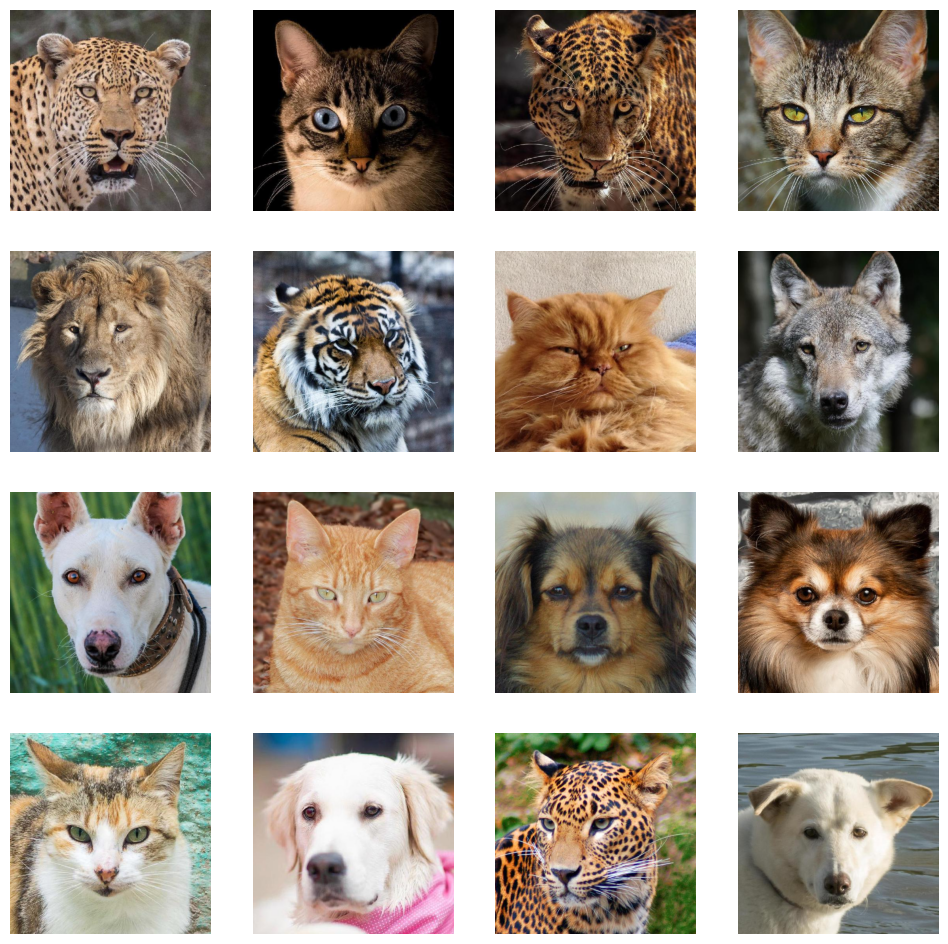

In [8]:
n_row = 4
n_col = 4
f, axarr = plt.subplots(n_row, n_col, figsize=(12, 12))

for row in range(n_row):
    for col in range(n_col):
        image = Image.open(data.sample(n = 1)['image_path'].iloc[0]).convert("RGB")
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')

In [9]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
print(data.columns)
print(data['label'].unique())
print(len(data['label'].unique()))

Index(['image_path', 'label'], dtype='object')
['cat' 'dog' 'wild']
3


In [12]:
class Net(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1) # First Convolution layer
      self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1) # Second Convolution layer
      self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1) # Third Convolution layer
      self.pooling = nn.MaxPool2d(2,2) # The pooling layer, we will be using the same layer after each conv2d.
      self.relu = nn.ReLU() # ReLU Activation function

      self.flatten = nn.Flatten() # Flatten and vectorize the output feature maps that somes from the final convolution layer.
      self.linear = nn.Linear((128 * 16 * 16), 128) # Traditional Dense (Linear)
      self.output = nn.Linear(128, len(data['label'].unique())) # Output Linear Layer


    def forward(self, x):
      x = self.conv1(x) # -> Outputs: (32, 128, 128)
      x = self.pooling(x)# -> Outputs: (32, 64, 64)
      x = self.relu(x)
      x = self.conv2(x) # -> Outputs: (64, 64, 64)
      x = self.pooling(x) # -> Outputs: (64, 32, 32)
      x = self.relu(x)
      x = self.conv3(x) # -> Outputs: (128, 32, 32)
      x = self.pooling(x) # -> Outputs: (128, 16, 16)
      x = self.relu(x)
      x = self.flatten(x)
      x = self.linear(x)
      x = self.output(x)

      return x

model = Net().to(device) # Create an instance of the model and move it to the GPU Device


In [13]:
from torchsummary import summary
summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [16]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  # Average loss per batch (not per 1000/100 — actual batch count)
  avg_train_loss = total_loss_train / len(train_loader)
  avg_val_loss = total_loss_val / len(val_loader)

  train_acc_pct = total_acc_train / len(train_dataset) * 100
  val_acc_pct = total_acc_val / len(val_dataset) * 100

  total_loss_train_plot.append(round(avg_train_loss, 4))
  total_loss_validation_plot.append(round(avg_val_loss, 4))
  total_acc_train_plot.append(round(train_acc_pct, 4))
  total_acc_validation_plot.append(round(val_acc_pct, 4))

  print(f'''Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(avg_train_loss, 4)} Train Accuracy: {round(train_acc_pct, 4)}
              Validation Loss: {round(avg_val_loss, 4)} Validation Accuracy: {round(val_acc_pct, 4)}''')
  print("="*25)

Epoch 1/10, Train Loss: 0.0147 Train Accuracy: 99.5395
              Validation Loss: 0.1729 Validation Accuracy: 95.4545
Epoch 2/10, Train Loss: 0.0122 Train Accuracy: 99.6457
              Validation Loss: 0.149 Validation Accuracy: 96.3223
Epoch 3/10, Train Loss: 0.0158 Train Accuracy: 99.4332
              Validation Loss: 0.14 Validation Accuracy: 96.1157
Epoch 4/10, Train Loss: 0.0072 Train Accuracy: 99.8406
              Validation Loss: 0.1483 Validation Accuracy: 96.405
Epoch 5/10, Train Loss: 0.0073 Train Accuracy: 99.7963
              Validation Loss: 0.2288 Validation Accuracy: 95.0826
Epoch 6/10, Train Loss: 0.0138 Train Accuracy: 99.5483
              Validation Loss: 0.1765 Validation Accuracy: 95.6198
Epoch 7/10, Train Loss: 0.0091 Train Accuracy: 99.7166
              Validation Loss: 0.1687 Validation Accuracy: 96.1983
Epoch 8/10, Train Loss: 0.0024 Train Accuracy: 99.9646
              Validation Loss: 0.1643 Validation Accuracy: 96.3223
Epoch 9/10, Train Loss: 0.00

In [17]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 96.5275 and Loss is 0.0268


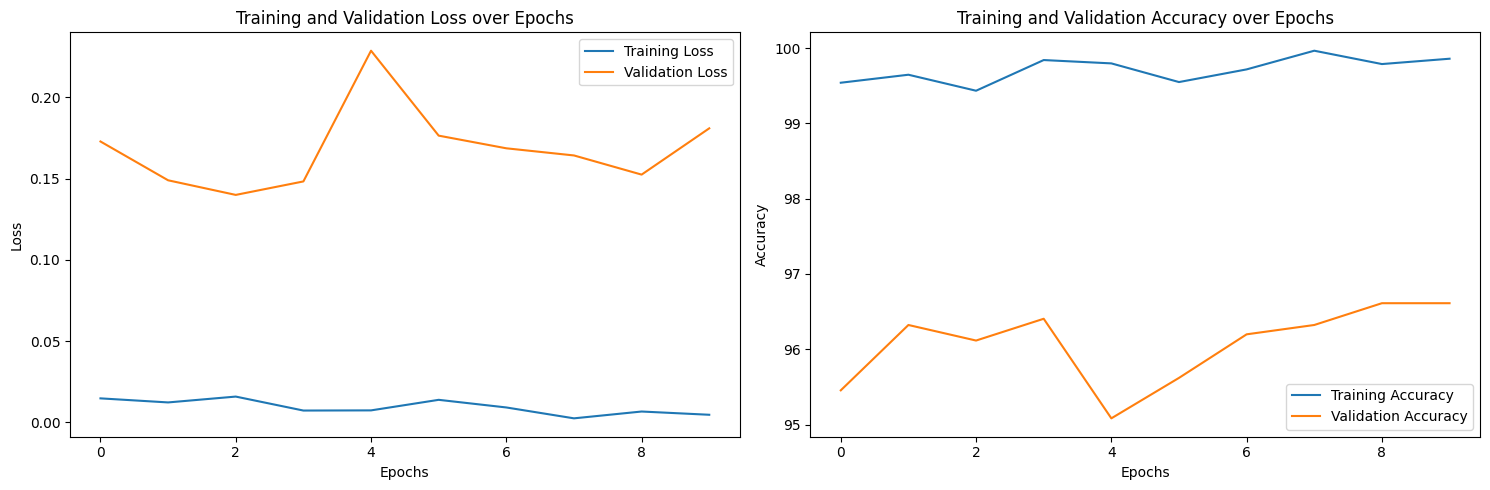

In [18]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()

In [24]:
import os

print(os.getcwd())


c:\Users\krish\OneDrive\Desktop\KrishCodex\AIML\ImageClassificationDL


In [26]:
import os

print(os.listdir())

['archive.zip', 'ImageClassification', 'imageclf.ipynb']


In [28]:
import os

print("Current directory:")
print(os.getcwd())

print("\nInside ImageClassification:")
print(os.listdir("ImageClassification"))

Current directory:
c:\Users\krish\OneDrive\Desktop\KrishCodex\AIML\ImageClassificationDL

Inside ImageClassification:
['afhq']


In [29]:
import os

print(os.listdir("ImageClassification/afhq"))

['train', 'val']


In [30]:
print(os.listdir("ImageClassification/afhq/train/cat")[:10])

['flickr_cat_000002.jpg', 'flickr_cat_000003.jpg', 'flickr_cat_000004.jpg', 'flickr_cat_000005.jpg', 'flickr_cat_000006.jpg', 'flickr_cat_000007.jpg', 'flickr_cat_000009.jpg', 'flickr_cat_000010.jpg', 'flickr_cat_000012.jpg', 'flickr_cat_000013.jpg']


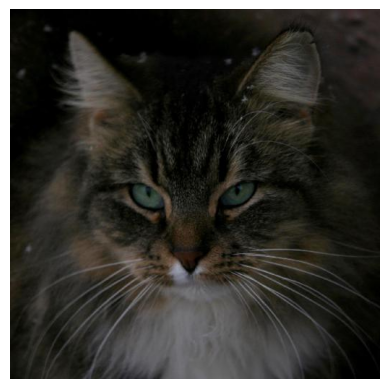

In [31]:
from PIL import Image
import matplotlib.pyplot as plt
import os

cat_folder = "ImageClassification/afhq/train/cat"

filename = os.listdir(cat_folder)[0]

image = Image.open(os.path.join(cat_folder, filename))

plt.imshow(image)
plt.axis("off")
plt.show()

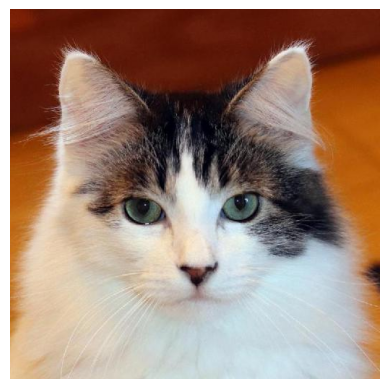

In [32]:
cat_folder = "ImageClassification/afhq/val/cat"

filename = os.listdir(cat_folder)[0]

image = Image.open(os.path.join(cat_folder, filename))

plt.imshow(image)
plt.axis("off")
plt.show()